In [1]:
import pandas as pd

In [2]:
homes=pd.read_csv('conjunto_de_datos_endutih_2024_csv/conjunto_de_datos/tr_endutih_hogares_anual_2024.csv')

C:\Users\Alejandra\AppData\Local\Temp\ipykernel_14056\3094386170.py:1: DtypeWarning: Columns (29,35,94) have mixed types. Specify dtype option on import or set low_memory=False.
  homes=pd.read_csv('conjunto_de_datos_endutih_2024_csv/conjunto_de_datos/tr_endutih_hogares_anual_2024.csv')


In [3]:
metadata=pd.read_csv('conjunto_de_datos_endutih_2024_csv/diccionario_de_datos/diccionario_de_datos_tr_endutih_hogares_anual_2024.csv')

In [4]:
homes = homes.astype({ #The columns that have mixed data types are converted to strings.
    'P4_6A': str,
    'P4_6_3': str,
    'P5_13A': str,
})

In [5]:
homes.info() #Information of the dataframe is obtained.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58080 entries, 0 to 58079
Columns: 104 entries, UPM to ESTATUS
dtypes: float64(57), int64(38), object(9)
memory usage: 46.1+ MB


# Data cleaning

In [7]:
#The following code write the columns with NA in a .txt file
na_count = homes.isna().sum()
columns_list_with_na = []
for i, (col, count) in enumerate(na_count.items()):
    question = metadata.iloc[i,1]
    columns_list_with_na.append(f"{i}; {col}; {question.replace("\n", " ")}; {count} \n")


with open("Columns_with_na.txt", "w", encoding="utf-8") as f:
    f.writelines(columns_list_with_na)

## Questions P4_1_4_1, P4_1_4_2, P4_1_6_1, P4_1_6_2, P4_2_1_2, P4_2_2_2, P4_2_3_2

*To analise the following questions and unsderstand the reasons of null values. The diagram of the survey was consulted.*

**The following groups of questions if people answered they did not have an item, they could not answered how many items they had neither their characteristics. That was the reason, in the following questons, the number of "NO" of the first question, and the number of NULL values of the following questions are the same.**

Group 1
P4_1_4; 4.1 Please let me know if you have the following items available: Flat-screen TV (digital television, LCD, or LED); "NO" = 9735

P4_1_4_1; 4.1 Please let me know if you have the following items available: Flat-screen TV (digital television, LCD, or LED). In total, how many flat-screen TVs do you have?; 9735  NULL
; P4_1_4_2; 4.Please let me know if you have the following items available: Flat-screen TV (digital television, LCD, or LED). In total, how many flat-screen TVs do you have? How many of these have Smart TV features (that connect directly to the internet or via a device)?)?; 9735 NULL

Group 2

P4_1_6; 4.1 Please let me know if you have the following items available: Mobile cell phone (owned by any member of the household).;"NO" = 2848 1; P4_1_6_1; 4Please let me know if you have the following items available: Mobile cell phone (owned by any member of the household). In total, how many cell phones are there in the household?ar?; 2 NULL842; P4_1_6_2; 4Please let me know if you have the following items available: Mobile cell phone (owned by any member of the household). How many of these are smartphones?e)?; 2 NULL848

Group 3

P4_2_1_1; 4.2 Do you have… a desktop computer (with the keyboard, monitor, and CPU as separate components)?; "NO" = 51637

P4_2_1_2; 4.2 Do you have a desktop computer (with the keyboard, monitor, and CPU as separate components)? How many desktop computers do you have?; 51637 null

Group 4

P4_2_2_1; 4.2 Do you have a laptop computer (with the keyboard, monitor, and CPU physically integrated)?; "NO" = 38381

P4_2_2_2; 4.2 Do you have a desktop computer (with the keyboard, monitor, and CPU as separate components)? How many laptop computers do you have?; 38381

Group 5

P4_2_3_1; 4.2 Do you have a tablet (with a virtual keyboard and stylus on the touchscreen)?; "NO" = 48376

P4_2_3_2; 4.2 Do you have a desktop computer (with the keyboard, monitor, and CPU as separate components)? How many tablets do you have?; 48376

The null values are raplaced by 0

In [17]:
homes[['P4_1_4_1', 'P4_1_4_2', 'P4_1_6_1', 'P4_1_6_2', 'P4_2_1_2', 'P4_2_2_2' ,'P4_2_3_2']] = homes[['P4_1_4_1', 'P4_1_4_2', 'P4_1_6_1', 'P4_1_6_2', 'P4_2_1_2' , 'P4_2_2_1','P4_2_3_2']].fillna(0)

## Question 4.3 Why don’t you have a computer, laptop, or tablet?

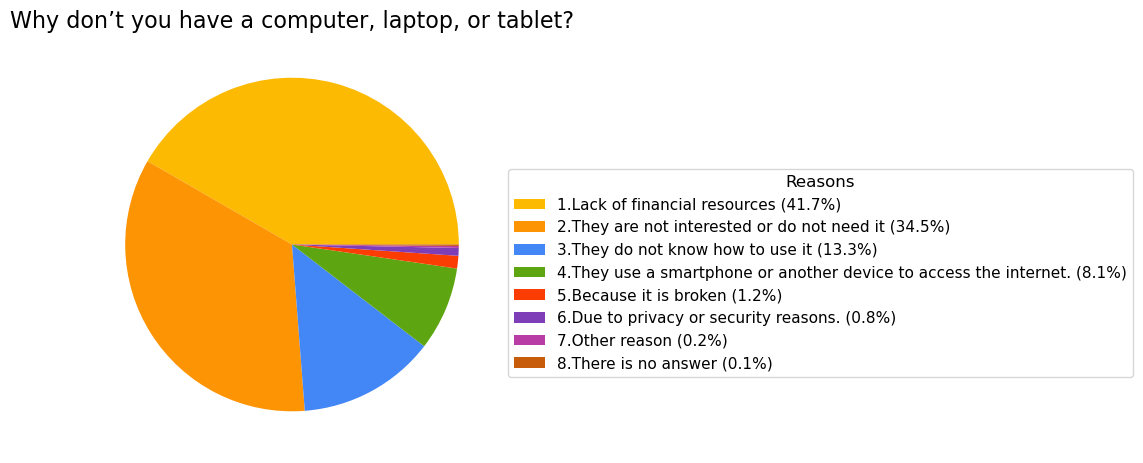

In [19]:
import matplotlib.pyplot as plt
counts = homes['P4_3'].value_counts()

percentages = counts / counts.sum() * 100


fig, ax = plt.subplots(figsize= (10, 8))

pie_labels = [
    '1.Lack of financial resources', 
    '2.They are not interested or do not need it',
    '3.They do not know how to use it',
    '4.They use a smartphone or another device to access the internet.',
    '5.Because it is broken',
    '6.Due to privacy or security reasons.',
    '7.Other reason',
    '8.There is no answer'
        ]

pie_colors = ['#fcba03', '#fc9403', '#4287f5', '#5ea611',
              '#fc3d03', '#7d3eb8', '#b83ea5', '#c75c0a']

legend_labels = [
    f"{label} ({pct:.1f}%)"
    for label, pct in zip(pie_labels, percentages)
        ]
wedges, _  = ax.pie(counts, labels= None, colors= pie_colors)

# Leyenda
ax.legend(
    wedges,
    legend_labels,
    title="Reasons",
    bbox_to_anchor=(1, 0.7),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Why don’t you have a computer, laptop, or tablet?',
    fontsize=16
)

plt.tight_layout()
plt.show()

For the question *P4_3, 4.3 Why don’t you have a computer, laptop, or tablet?*, it was analised that it should not be null values when one of the following questions have as answer "NO"  
P4_2_1_1  4.2 Do you have a desktop computer (with separate keyboard, monitor, and CPU)?  
P4_2_2_1  4.2 Do you have a laptop (with the keyboard, monitor, and CPU built into one unit)?  
P4_2_3_1  4.2 Do you have a tablet (with an on-screen virtual keyboard and pointer)?

In [21]:
#It counts the number of null vallues when the question P4_3 when P4_2_1_1, P4_2_2_1 or P4_2_3_1 were answered with "NO = 2"
count = (
    homes[['P4_2_1_1','P4_2_2_1','P4_2_3_1']]
    .eq(2)
    .any(axis=1)
    & homes['P4_3'].isna()
).sum()
print(f'Number of null values in question P4_3: {count}')

Number of null values in question P4_3: 23372


In [22]:
# The null values are replaced by the option 8 "There is no answer"
homes.loc[
    (
        (homes['P4_2_1_1'] == 2) |
        (homes['P4_2_2_1'] == 2) |
        (homes['P4_2_3_1'] == 2)
    ) &
    (homes['P4_3'].isna()),
    'P4_3'
] = 8

In [23]:
#It counts the number of null vallues when the question P4_3 when P4_2_1_1, P4_2_2_1 or P4_2_3_1 were answered with "YES"
count = (
    homes[['P4_2_1_1','P4_2_2_1','P4_2_3_1']]
    .eq(1)
    .all(axis=1)
    & homes['P4_3'].isna()
).sum()
print(f'Number of null values in question P4_3: {count}')

Number of null values in question P4_3: 1828


The rest of null values are replaced by 0 because the question *P4_3, 4.3 Why don’t you have a computer, laptop, or tablet?* is not applicable

In [25]:
homes[['P4_3']] = homes[['P4_3']].fillna(0)

## Question 4.5 Is the internet connection fixed (home/landline), mobile, or both?

There are 15442 null values in the question P4_5. It was verified how many people answered that they have internet access, question P4_4, and didn't answer the question P4_5.

In [28]:
count = (
    (homes['P4_4'].eq(1)) &
    (homes['P4_5'].isna())
).sum()
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 0


Now, it was verified how many people answered that they do not have internet access, question P4_4, and consequently, didn't answer the question P4_5 .

In [30]:
count = (
    (homes['P4_4'].eq(2)) &
    (homes['P4_5'].isna())
).sum()
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 15442


In this case, the number of null values are valid and just are replaced by the number 0 which means "Not applicable"

In [32]:
homes[['P4_5']] = homes[['P4_5']].fillna(0)

## Question 4.6 Is the fixed connection method through…

The following sentences were as option in the question *4.6 Is the fixed connection method through…*
 *P4_6_1; a dedicated telephone line (one that allows you to talk on the phone while connected to the internet).  
 P4_6_2; cable internet (commonly associated with paid TV service)?  
 P4_6_3; satellite connection (via a satellite dish antenna, not to be confused with dish antennas that provide services such as Sky or Dish)?  
 P4_6_4; an open Wi-Fi signal (external to your household)?  
 P4_6_5; dial-up telephone line (Dial-Up; while connected to the internet you cannot use the phone to talk)?  
 P4_6_6; another method?*  
     However, in the dataset they are different columns and each one has null values. Each column has 16951 null values in total, so it was analysed if these null values were valid.

The number of people who answered that they do not have a **fixed** Internet connection in their homes, so the question 4.6 is not applicable

In [36]:
count = (homes['P4_5'].isin([2,9,0])).sum()
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 16951


This is the number of null values of the columns P4_6_2, P4_6_3, P4_6_4, P4_6_5, P4_6_6. So the number of null values are valid and they are repalced by 0.

In [38]:
homes[['P4_6_1', 'P4_6_2', 'P4_6_3', 'P4_6_4', 'P4_6_5', 'P4_6_6']] = homes[['P4_6_1', 'P4_6_2', 'P4_6_3', 'P4_6_4', 'P4_6_5', 'P4_6_6']].fillna(0)

## Question 4.7 Which device(s) do you use for the mobile connection?

As the question 4.6, the question 4.7 has different options which constitute different columns in the dataset. The questions are the following:  
P4_7_1; 4.7 Con un celular inteligente (Smartphone)  
P4_7_2; 4.7 With a desktop or laptop computer connected to a mobile broadband card (BAM) or to a cellphone.  
P4_7_3; With a tablet with mobile network access.  
P4_7_4; Using a wireless modem with mobile network access.  
; P4_7_5Other device
Each variable registered 49156 null values.56 




It was assessed whether the number of null values matched the number of people whose response to question P4_5 caused question 4.7 to be marked as ‘not applicable.’

In [42]:
count = (homes['P4_5'].isin([1,9,0])).sum()
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 49156


So the number of null values is valid and these are full with 0

In [44]:
homes[['P4_7_1', 'P4_7_2', 'P4_7_3', 'P4_7_4', 'P4_7_5']] = homes[['P4_7_1', 'P4_7_2', 'P4_7_3', 'P4_7_4', 'P4_7_5']].fillna(0)

## Question 4.8 Why don't you have internet access home?

The options oof the answer are:
1) Lack of financial resources
2) They are not interested or do not need
3) They do not know how to use it
4) They are unaware of its usefulness
5) Insufficient equipment or lacking capacity
6) There is no service in their area (lack of infrastructure)
7) They have access to the internet in other places
8) For reasons related to privacy or security
9) Other reason
10) There is no answer

The question P4_8 had 42638 null values, so it was evaluated how many people should not have answered the question because they argumented that have Internet connection at their homes

In [47]:
#The number of people who have Internet connection so they cannot answered the question 4.8
count = (homes['P4_4'].eq(1)).sum()
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 42638


The number of null values corresponds with the number of people who cannot answer the question P4_8, so they are valid and replaced by 0, which means "not applicable"

In [49]:
homes[['P4_8']] = homes[['P4_8']].fillna(0)

## Questions P5_2_1, P5_2_2, P5_3_1, P5_3_2

The following questions reported the same number of null values, 36538.  
P5_2_1; 5.2 Do you get it through cable (Megacable, Izzi, etc.)?  
P5_2_2; 5.2 Do you receive it via satellite (Sky, Dish, etc.)?  
P5_3_1; 5.3 Do you share your pay TV service with another household?  
P5_3_2; 5.3 Do you share your pay TV service with a business inside or attached to the home (clinic, convenience store, stationery shop, etc.)?
First, we evaluated how many people could not answer the set of questions by determining how many reported not having pay TV. Question P5_1; 5.1 *Do you have pay TV service available?*

In [52]:
count = (homes['P5_1'].eq(2)).sum()
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 36538


The number of null values matches with the quantity of people who cannot answered the group of questions, so null values are replaced by 0

In [54]:
homes[['P5_2_1', 'P5_2_2', 'P5_3_1', 'P5_3_2']] = homes[['P5_2_1', 'P5_2_2', 'P5_3_1', 'P5_3_2']].fillna(0)

## Question P5_4; 5.4 Why do you not have pay TV service?

The question P5_4 had 21542 null values and the options of the question were:
1) Lack of financial resources
2) Not interested / do not need it
3) Do not have a television
4) No service available in the locality (lack of infrastructure)
5) Does not meet the household’s needs
6) Other reason

It was analysed how many could not answer the question. That is to say, how many people answer that they had pay TV.

In [57]:
#Question P5_1; 5.1 Do you have pay TV service? "Yes" = 1
count = (homes['P5_1'].eq(1)).sum() 
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 21542


The null values are valid so they will repalced by 0

In [59]:
homes[['P5_4']] = homes[['P5_4']].fillna(0)

## Question 5.8 or the services selected in (option from 5.7), please indicate whether they are bundled in a package or received separately.


P5_8_1; 5.8 For the services selected in (option from 5.7), please indicate whether they are bundled in a package or received separately.
   1) Pay TV, landline service, internet, and mobile phone service? 
   2) Pay TV, landline service, and internet?
   3) Pay TV and landline service?
   4) Pay TV and internet service?
   5) Landline service and internet?
   6) Only pay TV?
   7) Only landline service?
   8) Only internet service?

Each option represents a column in the dataset and each one had 1839 null values. It was verified that the null values corresponds to those people who claimed that hey did not have any service inthe question 5.7.

In [62]:
count = (homes['P5_7_5'].eq(1)).sum() 
print(f'Number of null values that comply with the condion is : {count}')

Number of null values that comply with the condion is : 1839


As the quantity of null values match with th number of people who could not answer the question. The null values are substituded for 0 *"Not applicable"*

In [64]:
homes[['P5_8_1','P5_8_2','P5_8_3','P5_8_4','P5_8_5','P5_8_6','P5_8_7','P5_8_8','P5_12_1','P5_12_2','P5_12_3']] = homes[['P5_8_1','P5_8_2','P5_8_3','P5_8_4','P5_8_5','P5_8_6','P5_8_7','P5_8_8','P5_12_1','P5_12_2','P5_12_3']].fillna(0)

## Question 5.9 In the last month, what was the amount paid for the service of …

The question 5.9 people could say how much money spent in each service. Each option represents a column in the dataset an each option had a different number of null values.

In the last month, what was the amount paid for the service of …

P5_9_1; Pay TV, landline telephone, internet, and mobile phone service?; 58019 null values
P5_9_2; Pay TV, landline telephone, and internet?; 50170 null values 
P5_9_3; Pay TV and landline telephone?; 57924 null values
P5_9_4; Pay TV and internet?; 51798 null values
P5_9_5; Landline telephone and internet?; 47883 null values
P5_9_6; Pay TV only?; 50468 null values
P5_9_7; Landline telephone only?; 56850 null values
P5_9_8; Internet only?; 41020
null values 

In [67]:
for a in range (52,80):
 if a == 52 or  a == 56 or  a == 60 or a ==  64 or  a == 68 or  a == 72 or  a == 75 or  a == 78: 
#52, 56, 60, 64, 68, 72, 75 or 78 are the columns or questions where people indicate what kind of service they
#of the question 5.8, 1 = "Yes", 2 = "No", 9 = "Uknown", 0 = "Not applicable"
    y = (homes.iloc[:,a] == 1).sum()
    n = (homes.iloc[:,a] == 2).sum()
    nk = (homes.iloc[:,a] == 9).sum() 
    na = (homes.iloc[:,a] == 0).sum()
    print(f"{a}  y's:{58080-y}, n's:{58080-n}, nks:{58080-nk}, na:{58080 - na}")

52  y's:58019, n's:2390, nks:57590, na:56241
56  y's:50170, n's:10032, nks:57797, na:56241
60  y's:57924, n's:2176, nks:57899, na:56241
64  y's:51798, n's:8400, nks:57801, na:56241
68  y's:47883, n's:12285, nks:57831, na:56241
72  y's:50468, n's:9540, nks:57991, na:56241
75  y's:56850, n's:3155, nks:57994, na:56241
78  y's:41020, n's:19039, nks:57940, na:56241


It was found that the null values corresponds to the number of people didn't confirm that they had that kind of package. In this case null values will not raplace with 0 because the variable is a numerical and replacing by 0 will alterate the analysis. 

## General data cleaning

Open questions are elimnated from the dataframe

In [71]:
homes = homes.drop(['P4_3A','P4_6A','P4_7A','P4_8A','P5_4A','P5_13A'], axis=1)

In [72]:
homes = homes.drop(['P5_10_1','P5_11_1','P5_10_2','P5_11_2','P5_10_3','P5_11_3',
                    'P5_10_4','P5_11_4','P5_10_5','P5_11_5','P5_10_6',
                    'P5_10_7','P5_10_8'], axis=1)

In [73]:
homes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58080 entries, 0 to 58079
Data columns (total 85 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   UPM       58080 non-null  int64  
 1   VIV_SEL   58080 non-null  int64  
 2   HOGAR     58080 non-null  int64  
 3   P4_1_1    58080 non-null  int64  
 4   P4_1_2    58080 non-null  int64  
 5   P4_1_3    58080 non-null  int64  
 6   P4_1_4    58080 non-null  int64  
 7   P4_1_4_1  58080 non-null  float64
 8   P4_1_4_2  58080 non-null  float64
 9   P4_1_5    58080 non-null  int64  
 10  P4_1_6    58080 non-null  int64  
 11  P4_1_6_1  58080 non-null  float64
 12  P4_1_6_2  58080 non-null  float64
 13  P4_2_1_1  58080 non-null  int64  
 14  P4_2_1_2  58080 non-null  float64
 15  P4_2_2_1  58080 non-null  int64  
 16  P4_2_2_2  58080 non-null  int64  
 17  P4_2_3_1  58080 non-null  int64  
 18  P4_2_3_2  58080 non-null  float64
 19  P4_3      58080 non-null  float64
 20  P4_4      58080 non-null  in

In [74]:
homes = homes.drop(['ESTATUS'], axis=1)

In [75]:
homes.loc[(homes['P4_6_3'] == "nan")] = 0

# Statistical Analysis

In [77]:
#It was assessed that the columns didnt have incorrect data entries or inconsistent formats after cleaning
for i, col in enumerate(homes.columns[:85]):
    print(i, col, homes[col].unique())

0 UPM [ 100110       0  100114 ... 3261035 3200646 3200655]
1 VIV_SEL [ 1  2  3  0  5  4  7  8 10 11 12 14 16 17 18 19  6  9 13 15 20 21 23 22
 24 26 29 30 31 32 37 38 39 25 27 28 33 36]
2 HOGAR [1 0 2 3 4 5]
3 P4_1_1 [1 2 0]
4 P4_1_2 [1 2 0]
5 P4_1_3 [1 0 2]
6 P4_1_4 [1 0 2]
7 P4_1_4_1 [ 1.  3.  0.  2.  4.  5.  8.  6.  7. 13. 99. 10. 22.  9.]
8 P4_1_4_2 [ 1.  2.  0.  3.  4. 99.  5.  8.  6.  7. 10.  9.]
9 P4_1_5 [1 2 0]
10 P4_1_6 [1 0 2]
11 P4_1_6_1 [ 3.  1.  7.  0.  4.  2.  5.  6.  8.  9. 10. 99. 43. 12. 11. 14. 24.]
12 P4_1_6_2 [ 3.  0.  7.  4.  1.  2.  5.  6.  8.  9. 10. 99. 11. 12. 14. 24.]
13 P4_2_1_1 [2 0 1]
14 P4_2_1_2 [ 0.  2.  1.  3.  4. 99. 11. 12.]
15 P4_2_2_1 [1 2 0]
16 P4_2_2_2 [1 2 0]
17 P4_2_3_1 [2 0 1]
18 P4_2_3_2 [ 0.  1.  2.  4.  3.  5.  6. 99.  8.]
19 P4_3 [8. 2. 5. 0. 1. 3. 4. 6. 7.]
20 P4_4 [1 0]
21 P4_5 [1. 0. 3.]
22 P4_6_1 [1. 2. 0.]
23 P4_6_2 [2. 1. 0.]
24 P4_6_3 ['2.0' 0 '1.0']
25 P4_6_4 [2. 0. 1.]
26 P4_6_5 [2. 0. 1.]
27 P4_6_6 [2. 0. 1.]
28 P4_7_1 [0. 1. 2.]


In [78]:
#A dataframe wih all the caegorical columns was built.
categorical_columns = homes.iloc[:, list(range(0,7)) +[9,10]+[13]+list(range(15,18))+list(range(20,47))+[49]+[51]+[53]+[55]+[57]+[59]+[61]+list(range(63,84))]

In [79]:
#It was verified that the dataframe only contains colmns with categorical variables
for i, col in enumerate (categorical_columns.columns[:85]):
    print(i, col, categorical_columns[col].unique())

0 UPM [ 100110       0  100114 ... 3261035 3200646 3200655]
1 VIV_SEL [ 1  2  3  0  5  4  7  8 10 11 12 14 16 17 18 19  6  9 13 15 20 21 23 22
 24 26 29 30 31 32 37 38 39 25 27 28 33 36]
2 HOGAR [1 0 2 3 4 5]
3 P4_1_1 [1 2 0]
4 P4_1_2 [1 2 0]
5 P4_1_3 [1 0 2]
6 P4_1_4 [1 0 2]
7 P4_1_5 [1 2 0]
8 P4_1_6 [1 0 2]
9 P4_2_1_1 [2 0 1]
10 P4_2_2_1 [1 2 0]
11 P4_2_2_2 [1 2 0]
12 P4_2_3_1 [2 0 1]
13 P4_4 [1 0]
14 P4_5 [1. 0. 3.]
15 P4_6_1 [1. 2. 0.]
16 P4_6_2 [2. 1. 0.]
17 P4_6_3 ['2.0' 0 '1.0']
18 P4_6_4 [2. 0. 1.]
19 P4_6_5 [2. 0. 1.]
20 P4_6_6 [2. 0. 1.]
21 P4_7_1 [0. 1. 2.]
22 P4_7_2 [0. 2. 1.]
23 P4_7_3 [0. 2. 1.]
24 P4_7_4 [0. 2. 1.]
25 P4_7_5 [0. 2. 1.]
26 P4_8 [0.]
27 P5_1 [2 0 1]
28 P5_2_1 [0. 1. 2.]
29 P5_2_2 [0. 2. 1.]
30 P5_3_1 [0. 2. 1.]
31 P5_3_2 [0. 2. 1.]
32 P5_4 [2. 0. 5. 1. 3. 4. 6.]
33 P5_5 [1 2 0]
34 P5_6 [1 2 0]
35 P5_7_1 [1 0]
36 P5_7_2 [2 0 1]
37 P5_7_3 [1 2 0]
38 P5_7_4 [1 0 2]
39 P5_7_5 [2 0]
40 P5_8_2 [2. 0. 1. 9.]
41 P5_8_3 [2. 0. 1. 9.]
42 P5_8_4 [2. 0. 1. 9.]
43 P5_8

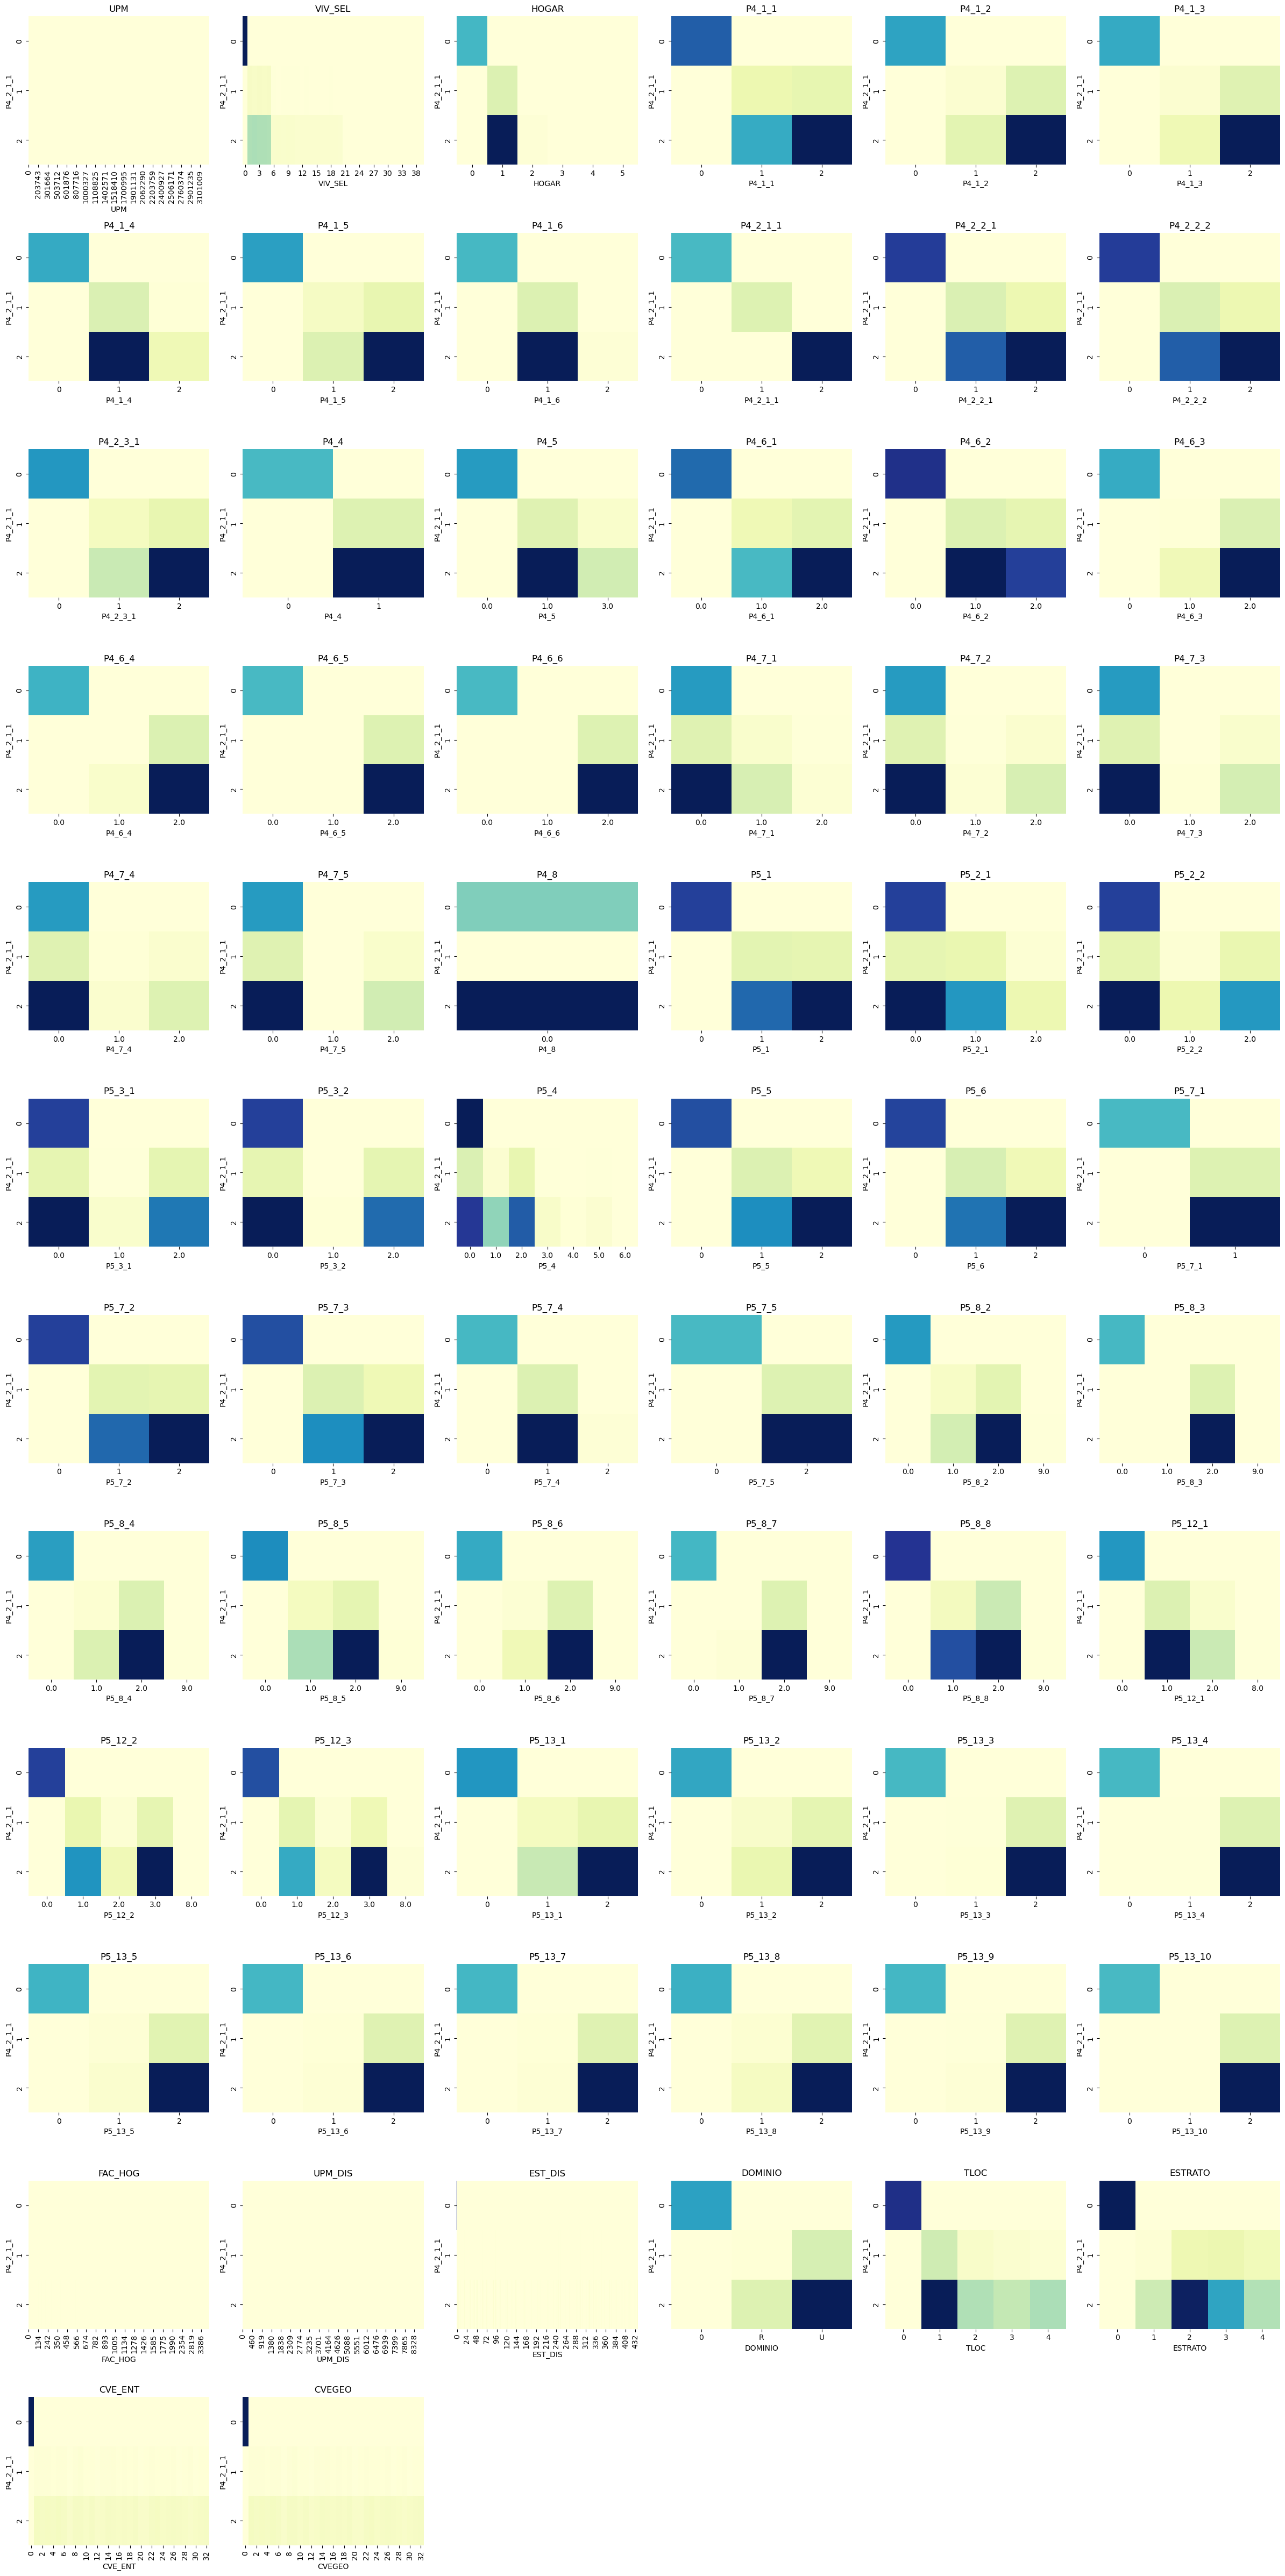

In [122]:
'''
Heatmaps are built to see the frequency of different combinations between variables.
The target variable is the column P4_2_1_1  4.2 Do you have a desktop computer 
(where the keyboard, monitor, and CPU are separate)?
'''
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

cols = categorical_columns.columns[:68]   
n = len(cols)

n_cols = 6                                # plots per row
n_rows = math.ceil(n / n_cols)             # compute needed rows

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()

for ax, column in zip(axs, cols):
    contingency_table = pd.crosstab(
        categorical_columns['P4_2_1_1'],
        categorical_columns[column]
    )
    
    sns.heatmap(contingency_table, cmap="YlGnBu", fmt='d', cbar=False, ax=ax)
    ax.set_title(column)

# hide unused axes
for ax in axs[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
categorical_columns = categorical_columns.iloc[:, list(range(2,60)) +list(range(63,66))]

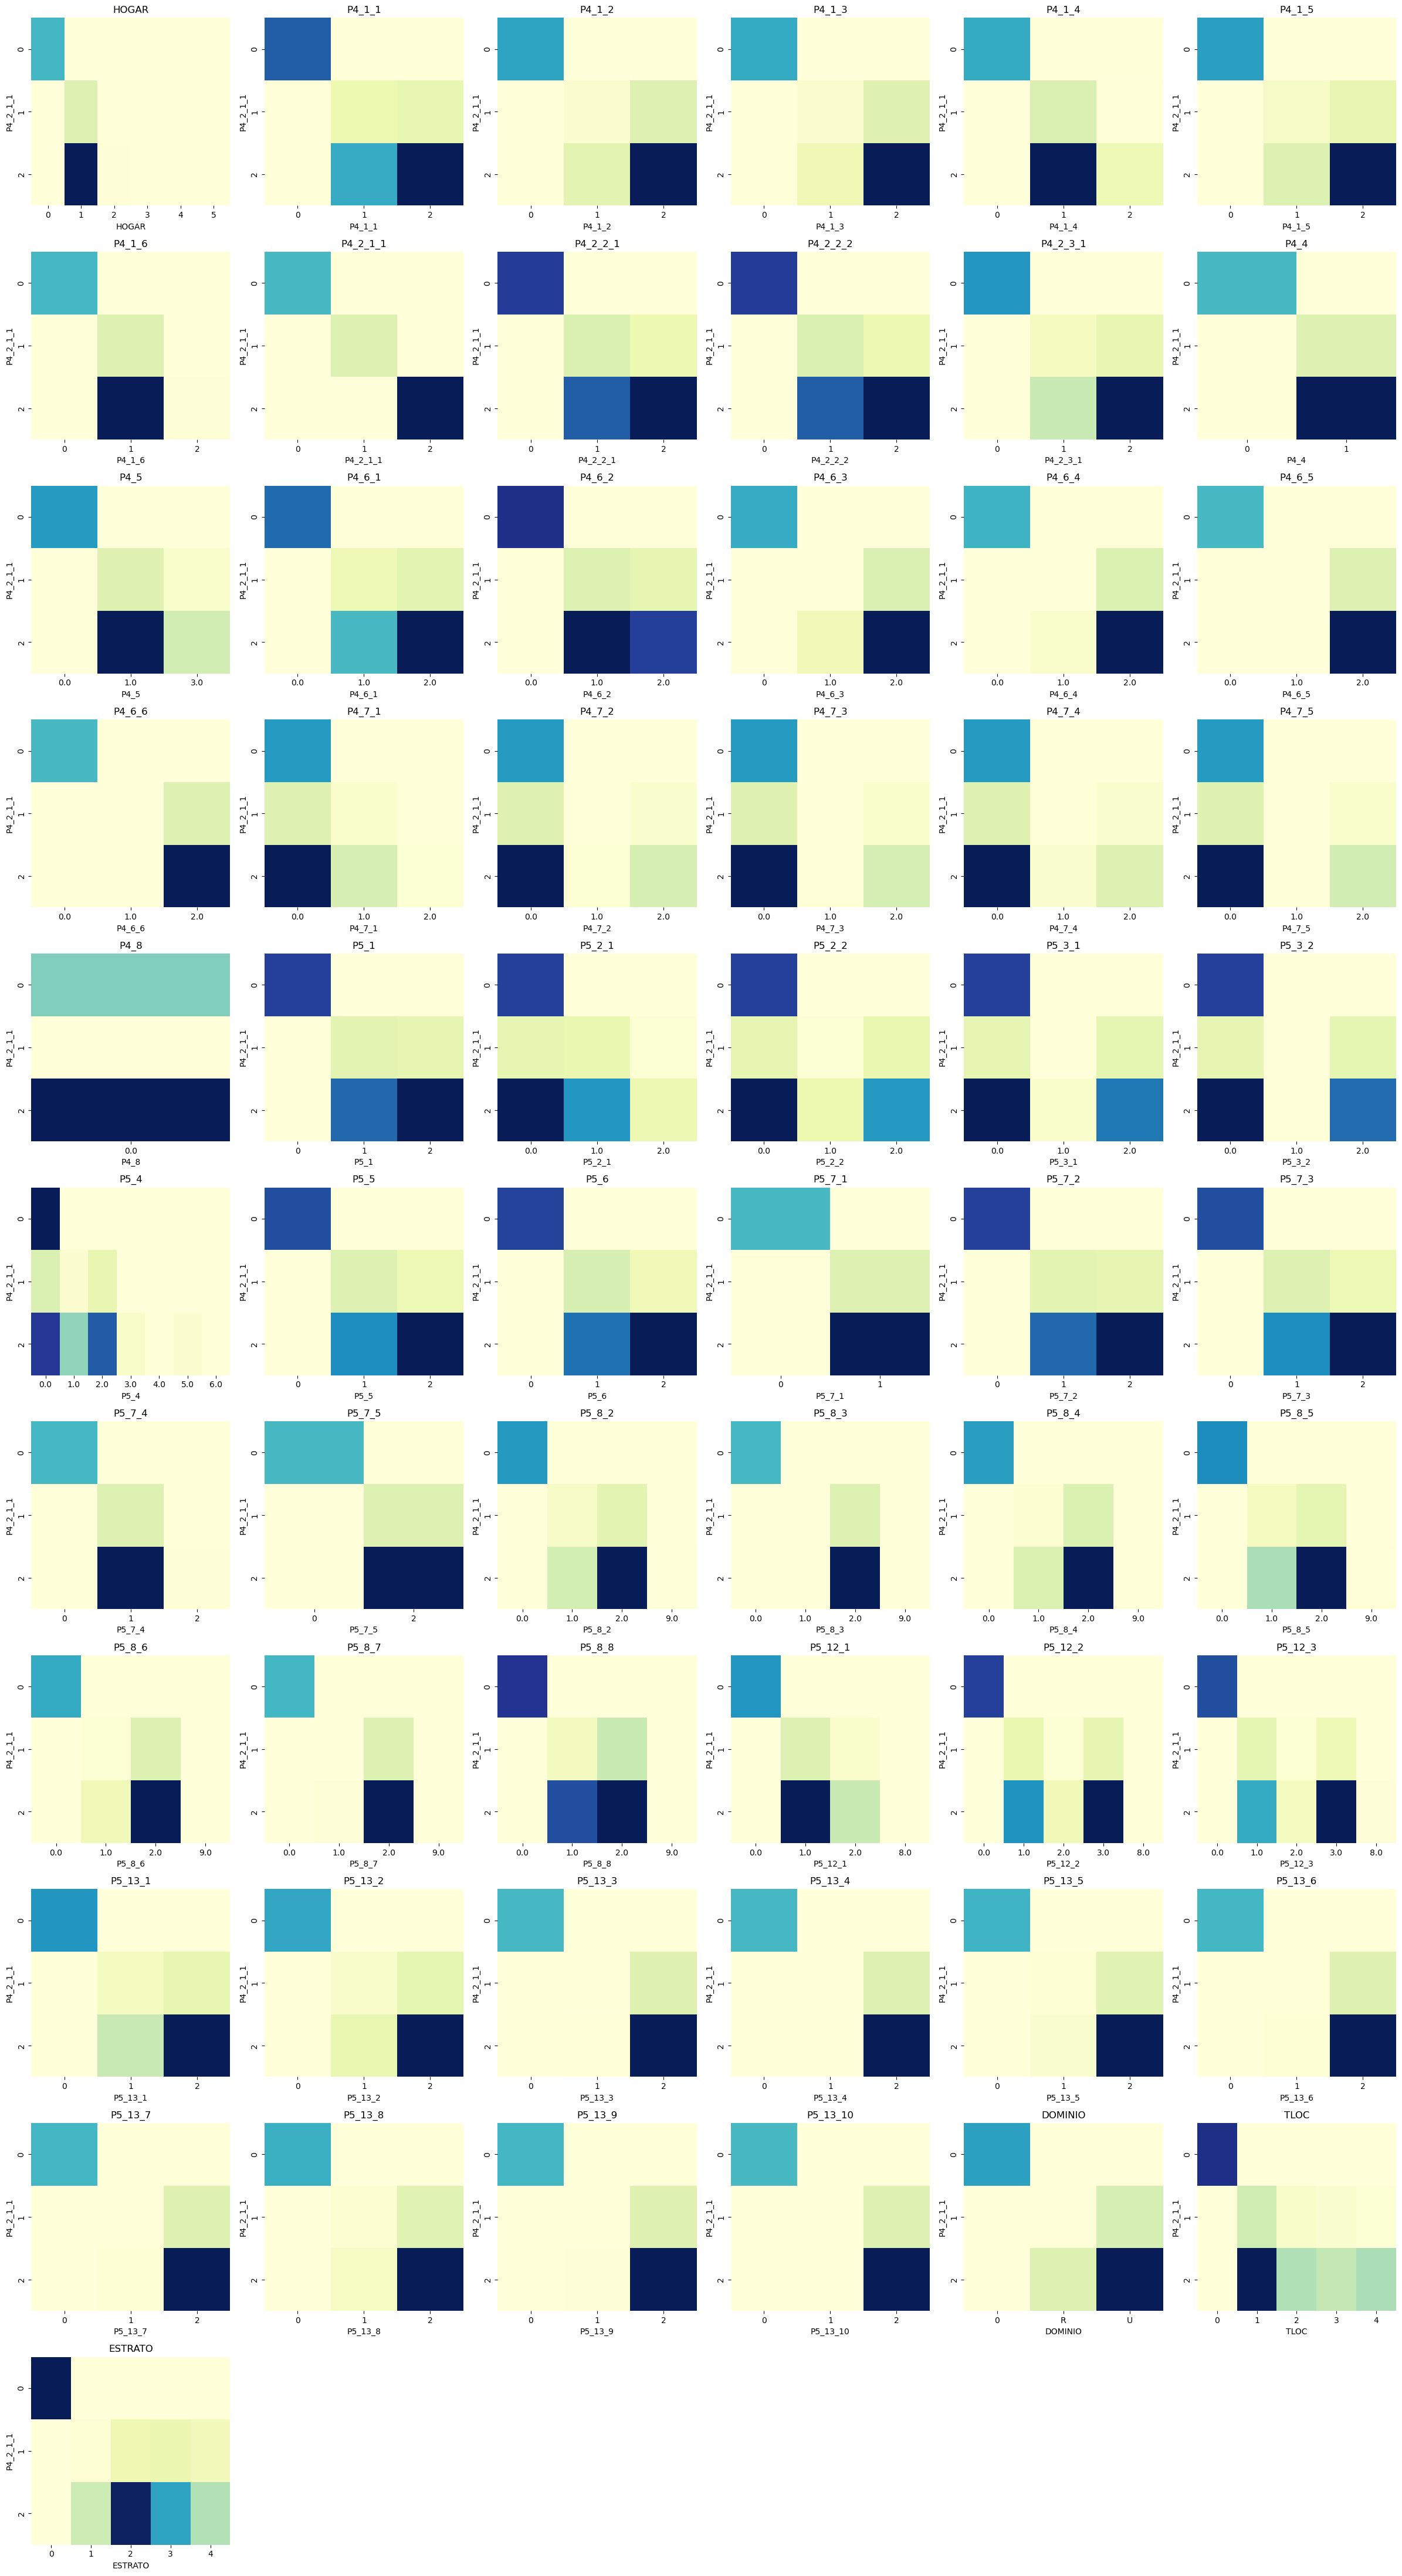

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

cols = categorical_columns.columns[:68]   
n = len(cols)

n_cols = 6                                # plots per row
n_rows = math.ceil(n / n_cols)             # compute needed rows

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()

for ax, column in zip(axs, cols):
    contingency_table = pd.crosstab(
        categorical_columns['P4_2_1_1'],
        categorical_columns[column]
    )
    
    sns.heatmap(contingency_table, cmap="YlGnBu", fmt='d', cbar=False, ax=ax)
    ax.set_title(column)

# hide unused axes
for ax in axs[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()